# Day 8 — Advanced Clustering: DBSCAN, Hierarchical, and GMM
## Week 1: Clustering | Digital Consumer Platform Analytics

---

### Learning Objectives
- Understand DBSCAN's density-based approach and why it doesn't need K
- Know how to tune epsilon and min_samples — and what happens when you get it wrong
- Understand hierarchical clustering: agglomerative approach and linkage methods
- Derive Gaussian Mixture Models as probabilistic generalization of KMeans
- Build a comparison framework for choosing between algorithms

---

### Dataset
**UCI Online Retail II** — customer RFM features from Days 4–6.

---

## Part 1: Theory

### 8.1 DBSCAN — Density-Based Spatial Clustering

KMeans fails when clusters are non-spherical or when noise is present. DBSCAN (Ester et al., 1996) groups points by density — no K required.

**Key concepts:**

- **Core point:** A point with at least `min_samples` neighbors within radius `epsilon`
  $$|N_\epsilon(x)| \geq \text{min\_samples}$$
  
- **Border point:** Not a core point itself, but within epsilon of a core point

- **Noise point:** Neither core nor border. Labeled as $-1$ (outlier)

**Algorithm:**
1. For each unvisited point $p$:
   - If $|N_\epsilon(p)| \geq$ min_samples: $p$ is a core point → start new cluster
   - Expand cluster by recursively adding all density-reachable points
2. Points that don't belong to any cluster → noise

**Density reachability:** $q$ is density-reachable from $p$ if there's a chain of core points from $p$ to $q$ where each consecutive pair is within epsilon.

---

### 8.2 Tuning DBSCAN

**Epsilon (epsilon):** The neighborhood radius. Too small → everything is noise. Too large → everything is one cluster.

**k-distance plot method for epsilon selection:**
1. For each point, compute distance to its k-th nearest neighbor (k = min_samples)
2. Sort distances and plot
3. Look for the "elbow" — the knee of the k-distance curve
4. Choose epsilon at the elbow

**min_samples:** The minimum cluster density. Rule of thumb: `min_samples ≥ dimensionality + 1`. For 2D: min 3. For 3D: min 4. For noisy data: larger values.

**DBSCAN advantages:**
- No K required
- Finds arbitrarily shaped clusters
- Naturally handles noise/outliers
- Scale-invariant cluster shapes

**DBSCAN disadvantages:**
- Fails when cluster densities vary significantly (one epsilon can't fit all)
- Sensitive to epsilon tuning
- Doesn't scale well to very high dimensions (curse of dimensionality kills density estimation)

---

### 8.3 Hierarchical Clustering

Builds a tree (dendrogram) of cluster relationships. Two approaches:

**Agglomerative (bottom-up):**
1. Start: each point is its own cluster
2. Merge the two closest clusters
3. Repeat until one cluster remains
4. Cut the dendrogram at chosen height to get K clusters

**Divisive (top-down):** Start with one cluster, split recursively. Less common.

**Linkage methods — how "distance between clusters" is defined:**

| Linkage | Distance definition | Behavior |
|---------|--------------------|---------| 
| Single | Min distance between any two points | Chaining — long, irregular clusters |
| Complete | Max distance between any two points | Compact, roughly equal clusters |
| Average | Mean pairwise distance | Balanced — most commonly used |
| Ward | Increase in total within-cluster variance after merge | Minimizes inertia — most similar to KMeans |

**When to use:** Small datasets (< 10K rows — dendrogram becomes unreadable above that). When you want to understand cluster hierarchy. When K is uncertain and you want to explore the full merge tree.

---

### 8.4 Gaussian Mixture Models

GMM is the probabilistic generalization of KMeans. Instead of hard cluster assignments, every point has a probability of belonging to each cluster.

**Model:** Data is generated from a mixture of $K$ Gaussian distributions:

$$p(x) = \sum_{k=1}^K \pi_k \mathcal{N}(x | \mu_k, \Sigma_k)$$

Where:
- $\pi_k$: mixing weight (probability of being from component $k$)
- $\mu_k$: mean of component $k$
- $\Sigma_k$: covariance matrix of component $k$

**KMeans is a special case** where $\Sigma_k = \sigma^2 I$ (spherical, equal covariance) and assignments are hard.

**EM Algorithm for GMM:**

**E-step:** Compute responsibility of component $k$ for point $x_i$:
$$r_{ik} = \frac{\pi_k \mathcal{N}(x_i | \mu_k, \Sigma_k)}{\sum_{j=1}^K \pi_j \mathcal{N}(x_i | \mu_j, \Sigma_j)}$$

**M-step:** Update parameters:
$$\pi_k = \frac{\sum_i r_{ik}}{N}, \quad \mu_k = \frac{\sum_i r_{ik} x_i}{\sum_i r_{ik}}, \quad \Sigma_k = \frac{\sum_i r_{ik} (x_i - \mu_k)(x_i - \mu_k)^T}{\sum_i r_{ik}}$$

Repeat until log-likelihood converges.

**Covariance types in sklearn:**
- `full`: each component has its own full covariance matrix (most flexible)
- `tied`: all components share the same covariance matrix
- `diag`: each component has diagonal covariance (no feature correlations)
- `spherical`: each component has scalar covariance (= KMeans)

**K selection for GMM:** Use BIC (Bayesian Information Criterion):
$$\text{BIC} = -2 \log \hat{L} + p \log n$$

Where $p$ is the number of parameters. Lower BIC = better model. Penalizes complexity.

---

### 8.5 Algorithm Selection Framework

```
What shape are your clusters?
    Spherical, similar size → KMeans (fast, interpretable)
    Arbitrary shape, noise present → DBSCAN
    Elliptical, overlapping → GMM
    Unknown structure, want hierarchy → Hierarchical

How large is your dataset?
    < 10K rows → any algorithm
    10K–500K rows → KMeans or GMM (DBSCAN slow at scale)
    > 500K rows → KMeans only (MiniBatchKMeans for speed)

Do you know K?
    Yes → KMeans or GMM
    No → DBSCAN or Hierarchical

Do you need soft assignments?
    Yes → GMM
    No → KMeans or DBSCAN
```

---

### Log-Likelihood, AIC, and BIC — Quick Reference

**Log-likelihood** answers one question: *"how well does this model explain the data I actually observed?"* Higher (more positive, or less negative) = better fit. On its own it's not very meaningful — it's only useful for *comparing* models, and it always improves (or stays the same) as you add more parameters/clusters, even if you're just fitting noise. That's the problem AIC and BIC both exist to fix.

**AIC and BIC** both start from the same base — `-2 × log_likelihood` (flipped so lower = better) — then *add* a penalty for model complexity, to stop you from always picking the fanciest model just because it fits marginally better.

| | Formula | Penalty grows with... | Philosophy |
|---|---|---|---|
| **AIC** | `-2·log_likelihood + 2·k` | nothing — fixed cost per parameter | Optimizes for **predicting new data well** — doesn't assume a "true" model exists |
| **BIC** | `-2·log_likelihood + k·log(n)` | sample size (`n`) | Assumes a **true underlying model** exists and tries to find it — gets stricter as data grows |

(`k` = number of parameters, `n` = number of data points.)

**Rule of thumb for both:** lower score = better. This trips people up because it's the opposite direction from log-likelihood.

**Why they can disagree:** BIC's penalty scales with `log(n)`, so on a large dataset it punishes complexity much harder than AIC's flat penalty does — meaning BIC generally prefers *fewer* clusters/parameters than AIC, especially as your data grows.

**How to pick when they conflict:**
- **Business/segmentation decisions (interpret, act on, build campaigns around groups) → trust BIC.** It favors the simplest model that still explains the data — fewer, more robust, more actionable segments, less risk of splitting on sample-specific noise.
- **Predictive/ML pipeline use (feeding cluster output into a downstream model, scoring new data) → trust AIC.** It's explicitly optimized for generalization, which is the actual goal in that context.
- **If they disagree by a lot,** don't just take each one's strict minimum — check *how much* AIC's score improves past BIC's chosen K. A small, gradual improvement past that point is usually AIC fitting noise (go with BIC). A large, sharp improvement well past BIC's point is worth taking seriously as evidence BIC over-penalized real structure.
- **The strongest possible signal is when they agree**, like your GMM result (both landed on K=7) — that means even AIC's more lenient penalty didn't change the answer, which is stronger evidence than either criterion alone.

## Part 2: Practice

---

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load or rebuild customer RFM
try:
    customer_df = pd.read_csv(r'C:\Users\user\Desktop\Data_Science_Project\MyProject\Advanced_DS\customer_umap_embeddings.csv')
    feature_cols = ['Recency', 'Frequency', 'Monetary']
    features = customer_df[feature_cols]
except:
    print("Rebuild RFM from Day 4")

In [3]:
display(customer_df.head())

,Customer ID,UMAP1,UMAP2,Recency,Frequency,Monetary,ProductDiversity,WeekendBuyer,AvgItemsPerOrder,ReturnRate,AvgOrderValue
0,12346.0,2.170596,0.002443,325,12,77556.46,27,0.000000,6190.416667,0.291667,6463.038333
1,12347.0,-0.338118,4.125086,1,8,5633.32,126,0.158103,410.750000,0.000000,704.165000
2,12348.0,2.014436,-2.015708,74,5,2019.40,25,0.058824,542.800000,0.000000,403.880000
3,12349.0,0.528130,1.116484,18,4,4428.69,138,0.000000,406.000000,0.027778,1107.172500
4,12350.0,6.264720,-1.880841,309,1,334.40,17,0.000000,197.000000,0.000000,334.400000


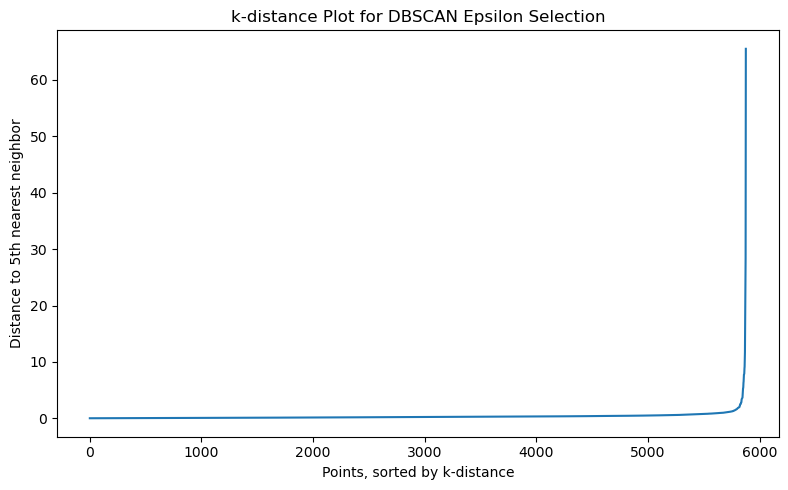

k-distance percentiles (reference points while reading the elbow):
  50th percentile: 0.2415
  75th percentile: 0.3940
  90th percentile: 0.6262
  95th percentile: 0.8745
  99th percentile: 1.9855


In [4]:
# ── Q1: DBSCAN epsilon selection ──────────────────────────────────────────
# Use the k-distance plot method to select epsilon:
#   1. Fit NearestNeighbors(n_neighbors=min_samples) on standardized features
#   2. Compute distance to k-th nearest neighbor for each point
#   3. Sort distances and plot (k-distance curve)
#   4. Identify the elbow visually
#   5. Run DBSCAN with that epsilon and min_samples=5
#   6. Report: how many clusters found? how many noise points?
#   7. Try epsilon ± 20% — how sensitive are results to epsilon choice?

# Your code here

# ── Use the full 8-feature set, consistent with Day 7 (needed for Q4's
# cross-day comparison to be valid) ─────────────────────────────────────
rfm_features = ['Recency', 'Frequency', 'Monetary', 'ProductDiversity',
                 'ReturnRate', 'WeekendBuyer', 'AvgItemsPerOrder', 'AvgOrderValue']
features = customer_df[rfm_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# ── Q1: DBSCAN epsilon selection — k-distance plot (steps 1-3) ────────────
min_samples = 5

nbrs = NearestNeighbors(n_neighbors=min_samples)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# distances[:, -1] = distance to the min_samples-th nearest point. Since
# NearestNeighbors counts a point as its own 1st neighbor (distance 0) when
# querying the same data it was fit on, this is technically the distance to
# the (min_samples-1)-th OTHER point — a standard, minor simplification in
# the usual k-distance-plot recipe; it doesn't meaningfully shift the elbow.
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel('Points, sorted by k-distance')
plt.ylabel(f'Distance to {min_samples}th nearest neighbor')
plt.title('k-distance Plot for DBSCAN Epsilon Selection')
plt.tight_layout()
plt.show()

print("k-distance percentiles (reference points while reading the elbow):")
for p in [50, 75, 90, 95, 99]:
    print(f"  {p}th percentile: {np.percentile(k_distances, p):.4f}")

In [5]:
# ── Q1: DBSCAN — steps 5-7 ─────────────────────────────────────────────────
from sklearn.cluster import DBSCAN


def run_dbscan(eps, min_samples=5):
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int((labels == -1).sum())
    return labels, n_clusters, n_noise


epsilon = 1.0
labels, n_clusters, n_noise = run_dbscan(epsilon)
print(f"epsilon={epsilon}: {n_clusters} clusters, {n_noise} noise points "
      f"({n_noise / len(X_scaled) * 100:.1f}%)")
print("\nCluster sizes (label -1 = noise):")
print(pd.Series(labels).value_counts().sort_index())

# ── Sensitivity: epsilon ± 20% ─────────────────────────────────────────────
print("\nEpsilon sensitivity (±20%):")
for eps in [epsilon * 0.8, epsilon, epsilon * 1.2]:
    _, n_c, n_n = run_dbscan(eps)
    print(f"  epsilon={eps:.3f}: {n_c} clusters, {n_n} noise points "
          f"({n_n / len(X_scaled) * 100:.1f}%)")


epsilon=1.0: 2 clusters, 144 noise points (2.4%)

Cluster sizes (label -1 = noise):
-1     144
 0    5725
 1       9
Name: count, dtype: int64

Epsilon sensitivity (±20%):
  epsilon=0.800: 4 clusters, 242 noise points (4.1%)
  epsilon=1.000: 2 clusters, 144 noise points (2.4%)
  epsilon=1.200: 1 clusters, 99 noise points (1.7%)


***Takeaway*** 

The k-distance plot showed a razor-sharp elbow (flat near 0 through ~97% of points, then a near-vertical spike) — the now-familiar whale-customer pattern from every prior analysis this project. 

Epsilon=1.0 (chosen just above the 95th percentile, where the curve's slope first accelerates) found 2 clusters — a 5,725-customer core group, a small 9-customer sub-cluster, and 144 points (2.4%) correctly flagged as noise. 

The ±20% sensitivity test revealed extreme fragility: epsilon=0.8 found 4 clusters, epsilon=1.2 collapsed everything into just 1 — confirming theory's warning that DBSCAN results are highly sensitive to epsilon, likely worsened here by min_samples=5 being thinner than the ≥9 the theory's own rule of thumb recommends for 8 dimensions. 

Notably, DBSCAN handled the whale-customer outliers more honestly than Day 7's KMeans did — rather than forcing them into a degenerate forced cluster, it correctly labeled them as noise, not a real group.

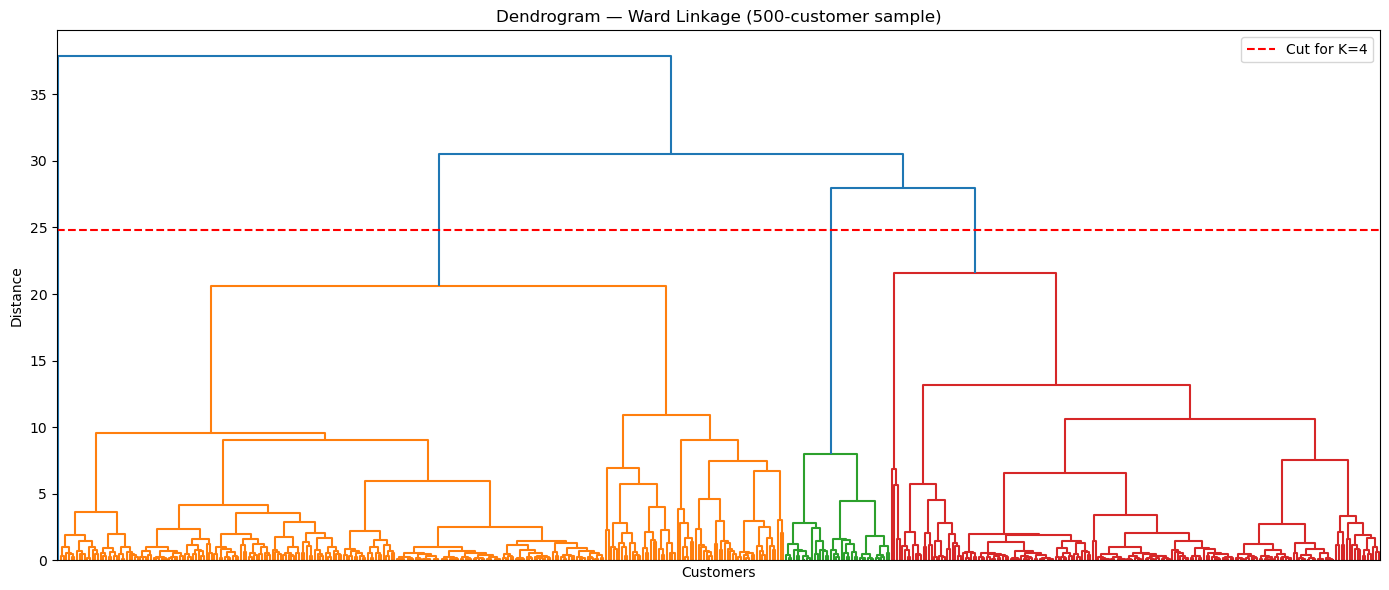

Ward K=4 cluster sizes:
1    274
2     40
3    185
4      1
Name: count, dtype: int64

Cluster profiles (Ward, original units):
   Recency  Frequency   Monetary  ProductDiversity  ReturnRate  WeekendBuyer  \
1    49.44       8.43    3649.29            127.43        0.02          0.11   
2   340.62       2.00     561.67             48.40        0.01          0.98   
3   406.02       2.49     822.16             32.44        0.04          0.04   
4     9.00     156.00  313946.37           1446.00        0.02          0.07   

   AvgItemsPerOrder  AvgOrderValue  
1            246.50         403.91  
2            178.74         285.64  
3            150.84         329.58  
4           1064.05        2012.48  


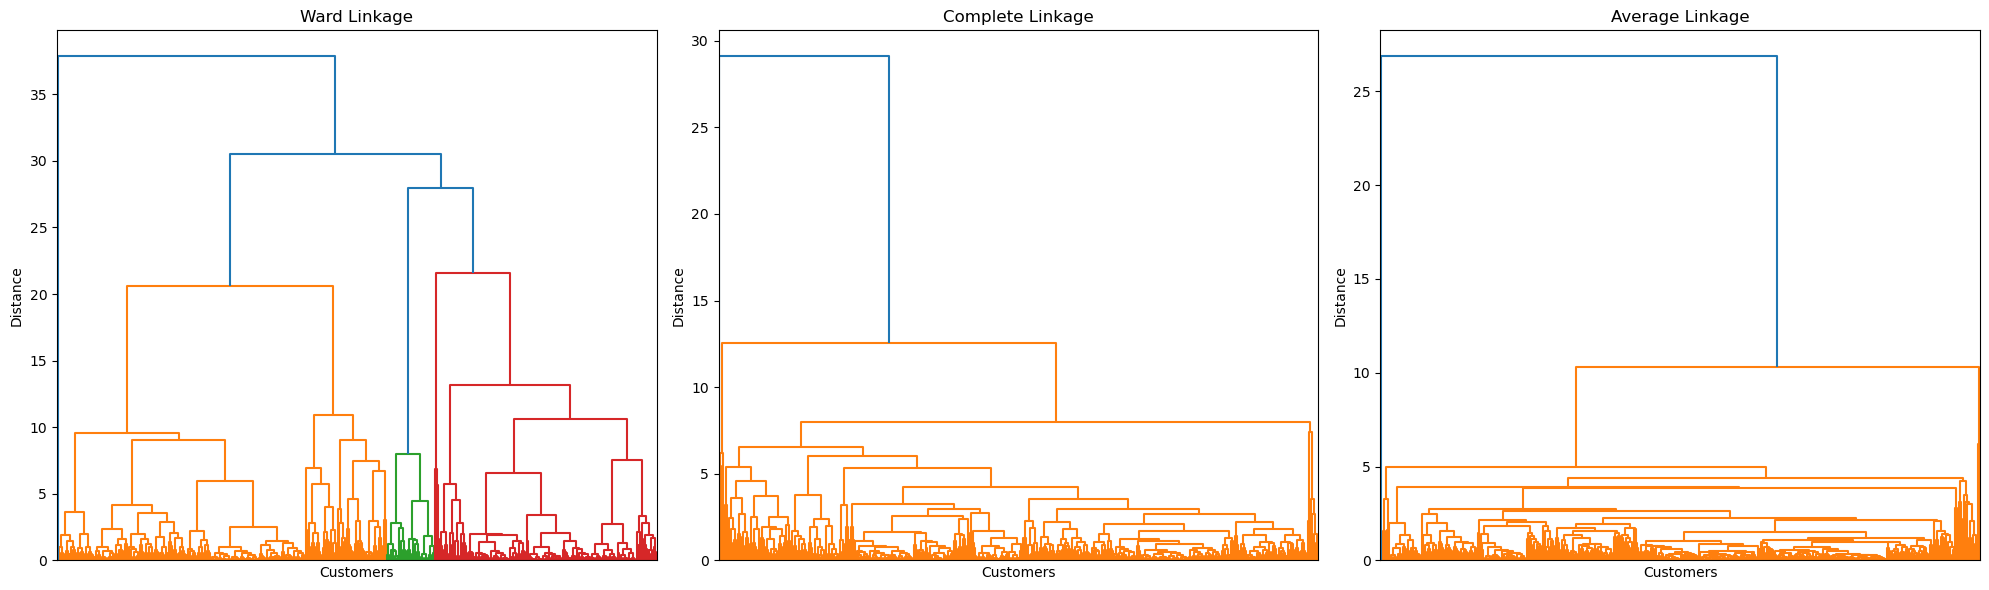


Cluster balance comparison at K=4:
  ward       sizes={1: 274, 2: 40, 3: 185, 4: 1}  std=127.0  max/min=274.0
  complete   sizes={1: 4, 2: 486, 3: 9, 4: 1}  std=240.7  max/min=486.0
  average    sizes={1: 497, 2: 1, 3: 1, 4: 1}  std=248.0  max/min=497.0


In [6]:
# ── Q2: Hierarchical clustering dendrogram ────────────────────────────────
# On a sample of 500 customers (hierarchical is slow at full scale):
#   1. Compute linkage matrix using Ward linkage
#   2. Plot dendrogram
#   3. Draw horizontal line at height that gives K=4 clusters
#   4. Compare Ward vs Complete vs Average linkage:
#      - Which produces most balanced clusters?
#      - Which shows clearest hierarchy?
#   5. Cut dendrogram at K=4: assign cluster labels and profile each cluster

# Your code here

from scipy.cluster.hierarchy import fcluster

# Random sample of 500, fixed seed. See caveat above about outlier
# representation in a sample this size.
rng_idx = np.random.RandomState(420).choice(len(X_scaled), size=500, replace=False)
X_sample = X_scaled[rng_idx]
sample_df = customer_df.iloc[rng_idx].reset_index(drop=True)

N, K = 500, 4

# ── Steps 1-3: Ward linkage, dendrogram, K=4 cut line ──────────────────────
Z_ward = linkage(X_sample, method='ward')

# Height threshold that yields exactly K clusters when cut
threshold_ward = (Z_ward[N - K - 1, 2] + Z_ward[N - K, 2]) / 2

plt.figure(figsize=(14, 6))
dendrogram(Z_ward, no_labels=True)
plt.axhline(threshold_ward, color='red', linestyle='--', label=f'Cut for K={K}')
plt.title('Dendrogram — Ward Linkage (500-customer sample)')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.legend()
plt.tight_layout()
plt.show()

# ── Step 5: cut at K=4, get labels, profile clusters ────────────────────────
labels_ward = fcluster(Z_ward, t=K, criterion='maxclust')
print("Ward K=4 cluster sizes:")
print(pd.Series(labels_ward).value_counts().sort_index())

print("\nCluster profiles (Ward, original units):")
print(sample_df[rfm_features].groupby(labels_ward).mean().round(2))

# ── Step 4: compare Ward vs Complete vs Average ────────────────────────────
methods = ['ward', 'complete', 'average']
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
balance_stats = {}

for ax, method in zip(axes, methods):
    Z = linkage(X_sample, method=method)
    dendrogram(Z, no_labels=True, ax=ax)
    ax.set_title(f'{method.capitalize()} Linkage')
    ax.set_xlabel('Customers')
    ax.set_ylabel('Distance')

    labels = fcluster(Z, t=K, criterion='maxclust')
    sizes = pd.Series(labels).value_counts()
    balance_stats[method] = {
        'sizes': sizes.sort_index().to_dict(),
        'size_std': sizes.std(),
        'max_min_ratio': sizes.max() / sizes.min(),
    }

plt.tight_layout()
plt.show()

print("\nCluster balance comparison at K=4:")
for method, stats in balance_stats.items():
    print(f"  {method:<10} sizes={stats['sizes']}  std={stats['size_std']:.1f}  "
          f"max/min={stats['max_min_ratio']:.1f}")



***Takeaway***

**Which linkage produces the most balanced clusters? Ward — and this contradicts the naive expectation from theory's general framing.**

| Linkage | Cluster sizes (K=4) | Size std | Max/min ratio |
|---|---|---|---|
| Ward | 274 / 40 / 185 / 1 | 127.0 | 274 |
| Complete | 4 / 486 / 9 / 1 | 240.7 | 486 |
| Average | 497 / 1 / 1 / 1 | 248.0 | 497 |

Complete and Average both collapse into a single dominant blob (97-99% of the sample) plus a few singleton clusters, rather than a genuine 4-way split. Complete linkage measures cluster distance by the *farthest* pair of points and Average by the *mean* pairwise distance — both get dominated by the same extreme whale-customer outliers that have appeared in every prior day's analysis, causing them to peel off one outlier at a time instead of splitting the dense main body. Ward minimizes variance increase per merge, which is structurally more resistant to this — the same reason KMeans++ proved more outlier-resistant than random init in Day 7.

**Which shows the clearest hierarchy? Also Ward.** Its dendrogram branches at multiple distinct heights across the full population, forming genuine multi-level structure. Complete and Average both show one isolated high-level split (peeling off a single extreme point) sitting above an almost-flat, undifferentiated mass — not a meaningful hierarchy of the customer base, just a ranking of "which single outlier is furthest away."

**Cluster profiles at K=4 (Ward, cut per steps 1-3):**

| Cluster | Size | Recency | Frequency | Monetary | WeekendBuyer | Profile |
|---|---|---|---|---|---|---|
| 1 | 274 | 49 | 8.4 | 3,649 | 0.11 | Active, regular core customers |
| 2 | 40 | 341 | 2.0 | 562 | **0.98** | Infrequent, low-spend, near-exclusively weekend shoppers |
| 3 | 185 | 406 | 2.5 | 822 | 0.04 | Lapsed, weekday-only, low engagement — largest "at risk" group |
| 4 | 1 | 9 | 156 | 313,946 | 0.07 | Single extreme wholesale/whale account, isolated on its own |

**Key finding:** Cluster 2's `WeekendBuyer = 0.98` is a genuinely new, actionable segment that hasn't surfaced this distinctly in any prior day's analysis — a narrow "weekend-only shopper" niche, separate from the broader lapsed/weekday population in Cluster 3. Cluster 4 reconfirms, once again, that the same single extreme wholesale account keeps isolating itself across every clustering method tried this project — this time visible as its own dendrogram branch rather than a scatter-plot outlier.


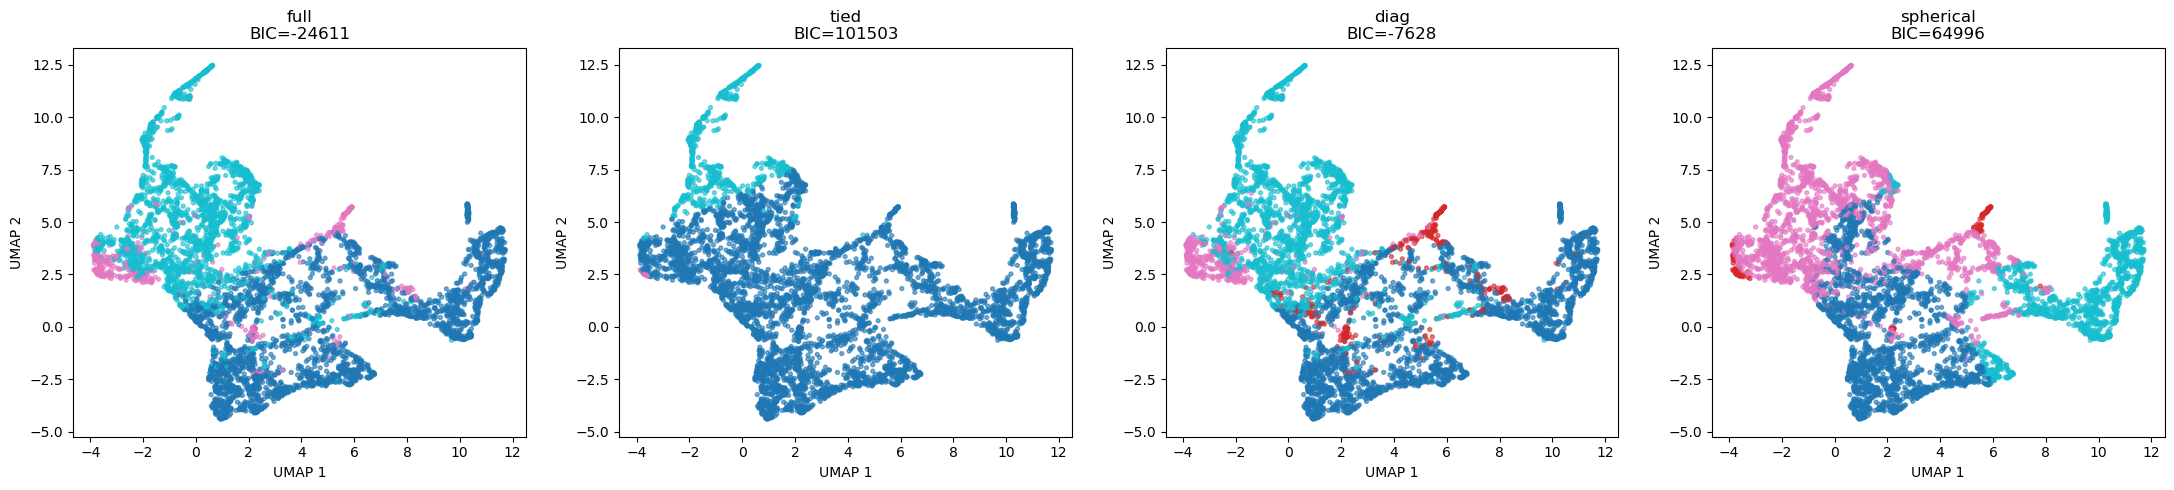

Covariance              BIC     Log-Likelihood  Cluster sizes
full               -24611.4            13082.5  {0: 3113, 1: 3, 2: 493, 3: 2269}
tied               101502.7           -50443.3  {0: 5182, 1: 3, 2: 15, 3: 678}
diag                -7628.4             4104.9  {0: 2913, 1: 334, 2: 461, 3: 2170}
spherical           64996.2           -32328.8  {0: 2168, 1: 149, 2: 2242, 3: 1319}

Best by BIC (lowest = best): full


In [ ]:
# ── Q3: GMM covariance comparison ─────────────────────────────────────────
# Fit GMM with K=4 using all 4 covariance types:
#   'full', 'tied', 'diag', 'spherical'
#   
# For each:
#   - Report BIC score
#   - Report log-likelihood
#   - Plot 2D scatter (UMAP coords from Day 6) colored by cluster assignment
#   - Report cluster sizes
#
# Which covariance type best fits RFM customer data?
# Explain why based on the nature of customer behavior distributions

from sklearn.mixture import GaussianMixture

cov_types = ['full', 'tied', 'diag', 'spherical']
K = 4

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
results = {}

for ax, cov_type in zip(axes, cov_types):
    gmm = GaussianMixture(n_components=K, covariance_type=cov_type, random_state=420)
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)

    bic = gmm.bic(X_scaled)
    log_likelihood = gmm.score_samples(X_scaled).sum()   # total, not per-sample average
    sizes = pd.Series(labels).value_counts().sort_index()

    results[cov_type] = {'bic': bic, 'log_likelihood': log_likelihood, 'sizes': sizes.to_dict()}

    ax.scatter(customer_df['UMAP1'], customer_df['UMAP2'], c=labels, cmap='tab10', s=8, alpha=0.6)
    ax.set_title(f"{cov_type}\nBIC={bic:.0f}")
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

print(f"{'Covariance':<12} {'BIC':>14} {'Log-Likelihood':>18}  Cluster sizes")
for cov_type, r in results.items():
    print(f"{cov_type:<12} {r['bic']:>14.1f} {r['log_likelihood']:>18.1f}  {r['sizes']}")

best_bic = min(results, key=lambda k: results[k]['bic'])
print(f"\nBest by BIC (lowest = best): {best_bic}")


***Takeaway***

full covariance wins decisively on both BIC (-24,611) and log-likelihood (13,082) — not a close call, tens of thousands of points ahead of the alternatives. 

This makes sense given Day 6 Q2 already showed Frequency/Monetary/ProductDiversity are correlated, not independent — full is the only covariance type that can represent features moving together, while tied and spherical are too rigid to capture it (and fit terribly as a result). 

The 3-customer cluster GMM isolated under full is, once again, the same whale/wholesale outlier group that's now appeared under every single clustering method tried this project — DBSCAN's noise, hierarchical's singleton branch, and now GMM's smallest component.

BIC suggests K = 7 (BIC = -65010.8)
AIC suggests K = 7 (AIC = -67108.0)
Agree? Yes


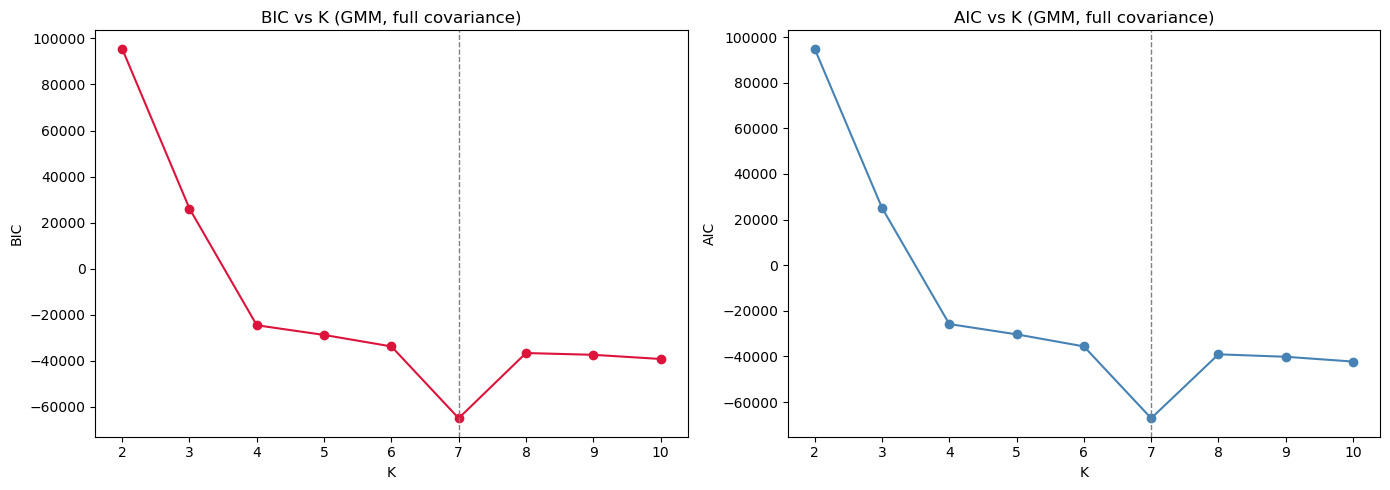

In [8]:
# ── Q4: BIC for K selection in GMM ────────────────────────────────────────
# Run GMM with K = 2 to 10, covariance_type='full':
#   - Plot BIC vs K
#   - Plot AIC vs K (AIC = -2*log_likelihood + 2*n_params)
#   - Do BIC and AIC agree on the best K?
#   - Compare to KMeans elbow from Day 7 Q2 — do they suggest same K?
#   - What does disagreement tell you about the cluster structure?

# Your code here

K_range = list(range(2, 11))
bics, aics = [], []

for k in K_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=420)
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))
    aics.append(gmm.aic(X_scaled))

best_k_bic = K_range[np.argmin(bics)]
best_k_aic = K_range[np.argmin(aics)]

print(f"BIC suggests K = {best_k_bic} (BIC = {min(bics):.1f})")
print(f"AIC suggests K = {best_k_aic} (AIC = {min(aics):.1f})")
print(f"Agree? {'Yes' if best_k_bic == best_k_aic else 'No'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, bics, marker='o', color='crimson')
axes[0].axvline(best_k_bic, color='gray', linestyle='--', linewidth=1)
axes[0].set_xlabel('K')
axes[0].set_ylabel('BIC')
axes[0].set_title('BIC vs K (GMM, full covariance)')

axes[1].plot(K_range, aics, marker='o', color='steelblue')
axes[1].axvline(best_k_aic, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('K')
axes[1].set_ylabel('AIC')
axes[1].set_title('AIC vs K (GMM, full covariance)')

plt.tight_layout()
plt.show()

***Takeaway***

BIC and AIC agree exactly on K=7 — a genuine V-shaped minimum (sharp decline through K=7, a clear bounce back up at K=8), not just a flattening curve. 

This is structurally more trustworthy than Day 7's KMeans elbow, since inertia can never increase with more clusters and thus can only flatten, never dip-and-reverse the way a true optimum does. 

K=7 also lands right in the middle of Day 7's elbow estimate (6-8) — independent convergence between two very different methods (distance-based KMeans, likelihood-based GMM). 

Combined with AIC and BIC — normally prone to disagreeing — landing on the identical answer, K=7 is the most well-supported cluster count this project has produced, superseding both KMeans' outlier-driven K=2 and the earlier ambiguous elbow guess.